# Shock episodes
This notebook compares changes in EFW (and GDP per capita where available)
across defined historical episodes to highlight cross-country responses.

In [1]:
from __future__ import annotations

import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

ROOT = Path.cwd().resolve()
if not (ROOT / "src").exists() and (ROOT.parent / "src").exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.maps import load_world_geometries, merge_world_data, plot_choropleth
from src.paths import CLEAN_DIR, LOGS_DIR, OUTPUT_DIR
from src.viz_style import savefig, set_style

In [2]:
set_style()
panel_path = CLEAN_DIR / "panel_quinquennial_atlas.parquet"
if not panel_path.exists():
    raise FileNotFoundError("Missing atlas panel. Run 03_build_quinquennial_panel first.")

config = json.loads((LOGS_DIR / "run_config.json").read_text())
episodes = config["episodes"]

panel = pd.read_parquet(panel_path)
world = load_world_geometries()

,iso3c,country_name,d_efw
174,NPL,Nepal,1.060000
66,ECU,Ecuador,0.550000
140,LUX,Luxembourg,0.540000
42,CMR,Cameroon,0.470000
92,GTM,Guatemala,0.450000
105,IDN,Indonesia,0.390000
203,SEN,Senegal,0.350000
95,HKG,"Hong Kong SAR, China",0.330000
100,HUN,Hungary,0.280000
219,SWE,Sweden,0.220000


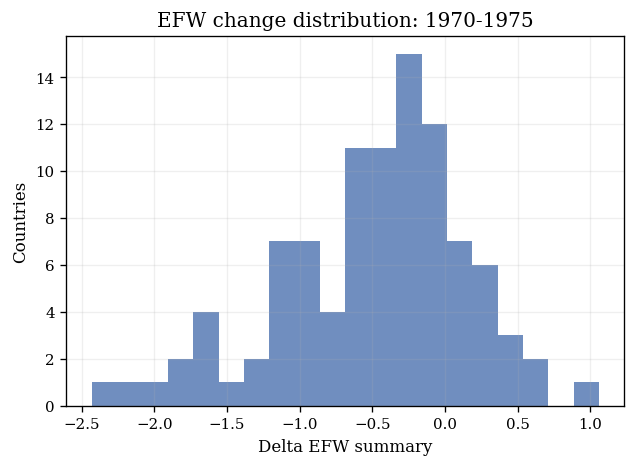

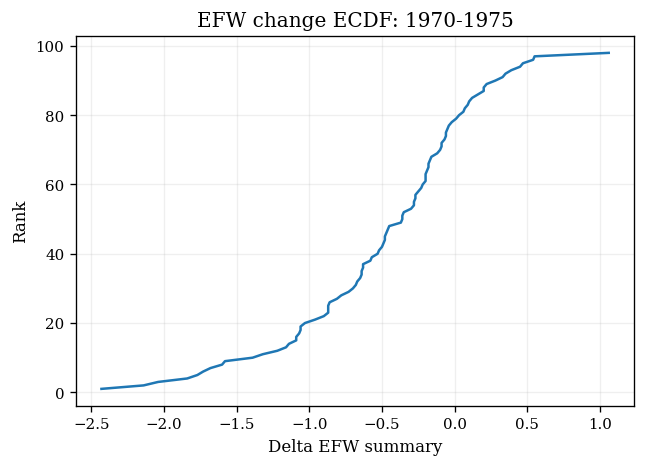

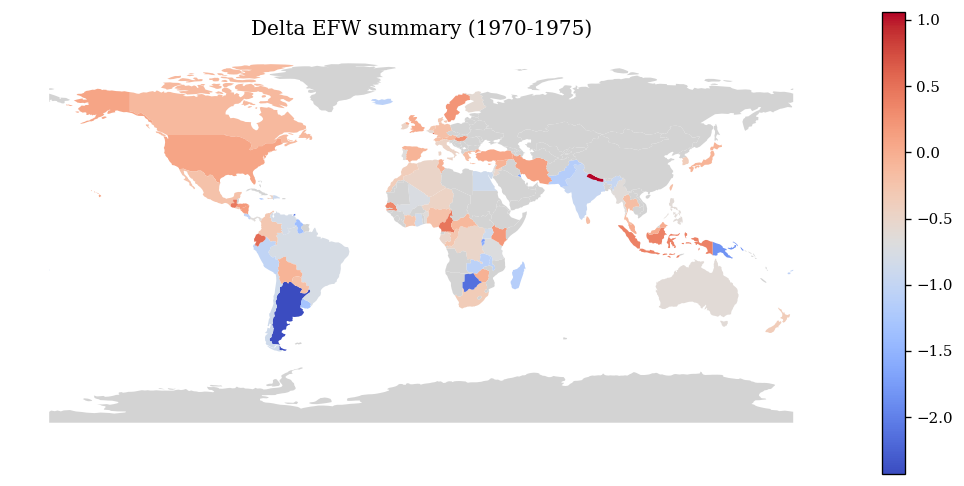

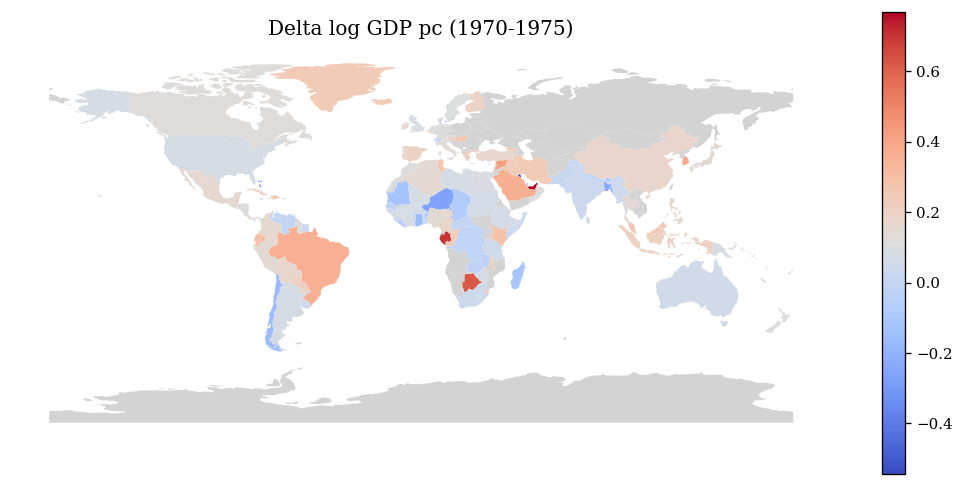

,iso3c,country_name,d_efw
81,GBR,United Kingdom,1.970000
199,RWA,Rwanda,1.600000
39,CHL,Chile,1.550000
178,OMN,Oman,1.380000
163,MUS,Mauritius,1.340000
22,BHR,Bahrain,1.340000
80,GAB,Gabon,1.330000
190,PRT,Portugal,1.120000
185,PNG,Papua New Guinea,1.020000
246,URY,Uruguay,1.010000


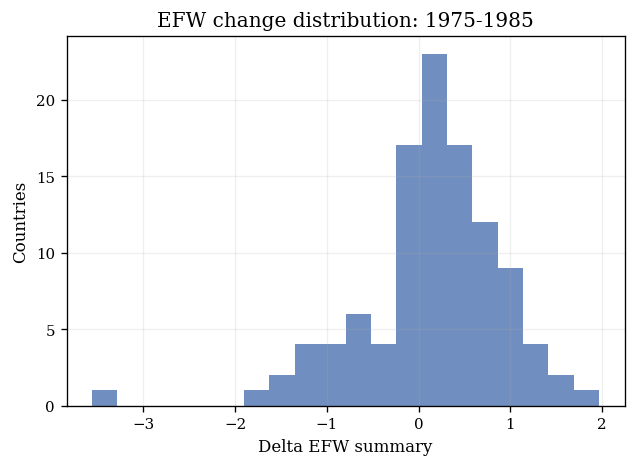

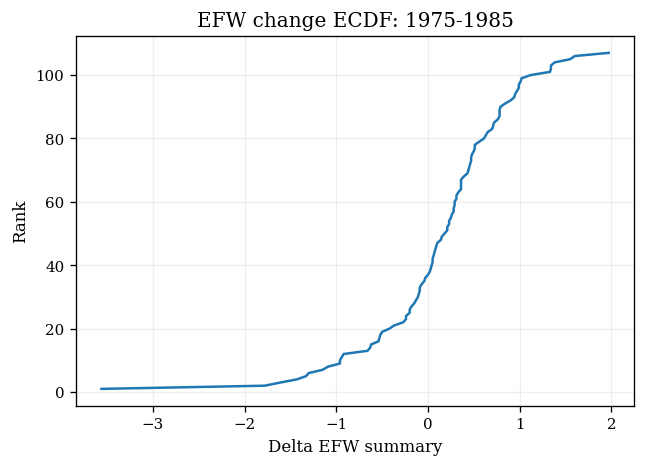

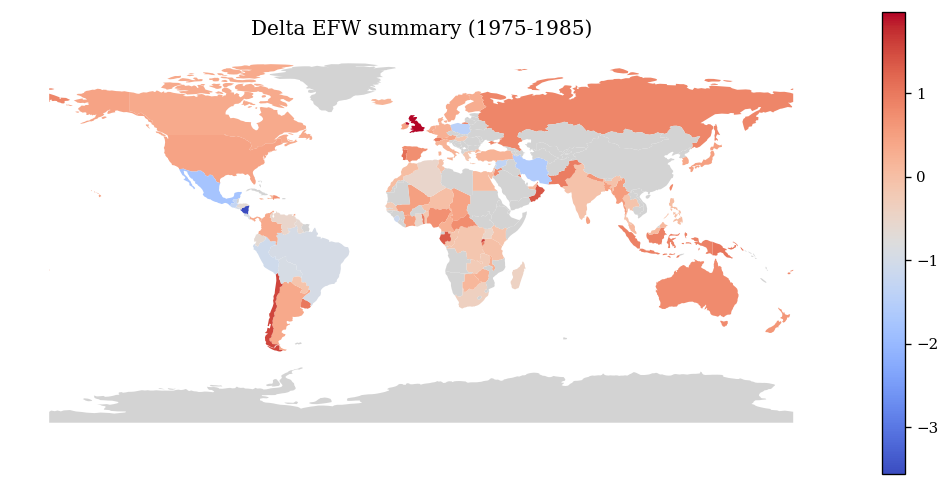

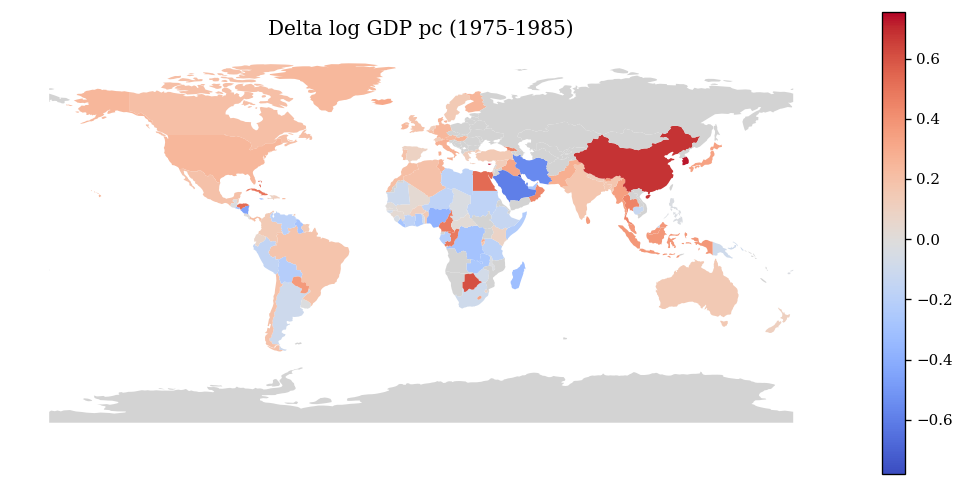

,iso3c,country_name,d_efw
22,BHR,Bahrain,1.510000
190,PRT,Portugal,1.170000
39,CHL,Chile,1.090000
81,GBR,United Kingdom,0.990000
59,DOM,Dominican Republic,0.970000
199,RWA,Rwanda,0.810000
174,NPL,Nepal,0.740000
9,ARG,Argentina,0.730000
154,MLI,Mali,0.620000
37,CHE,Switzerland,0.620000


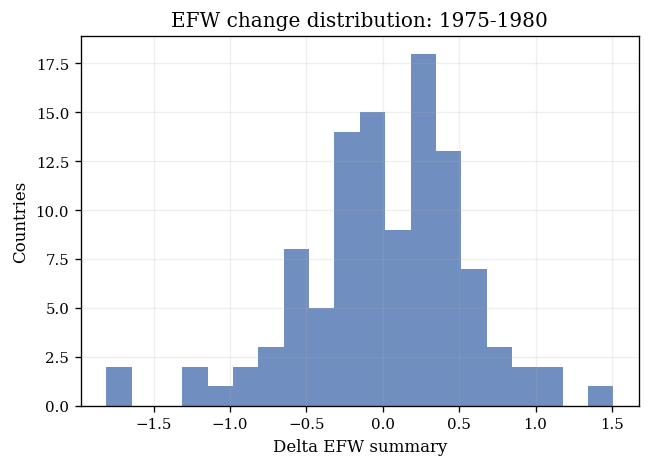

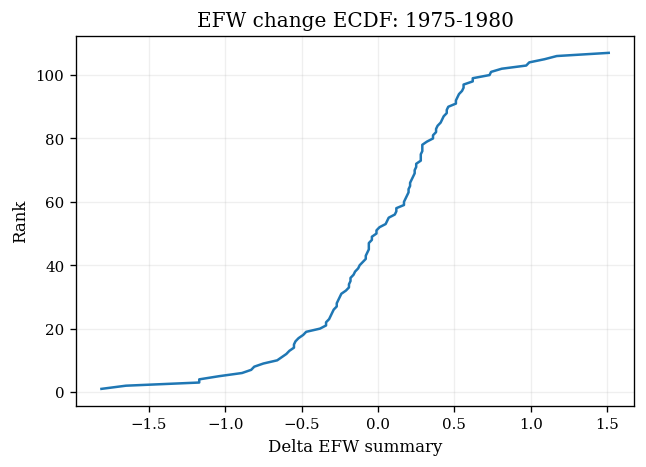

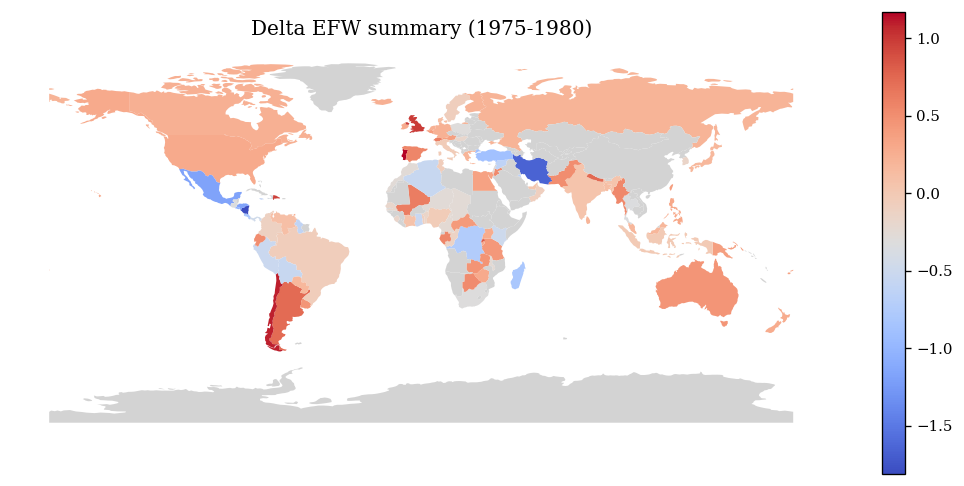

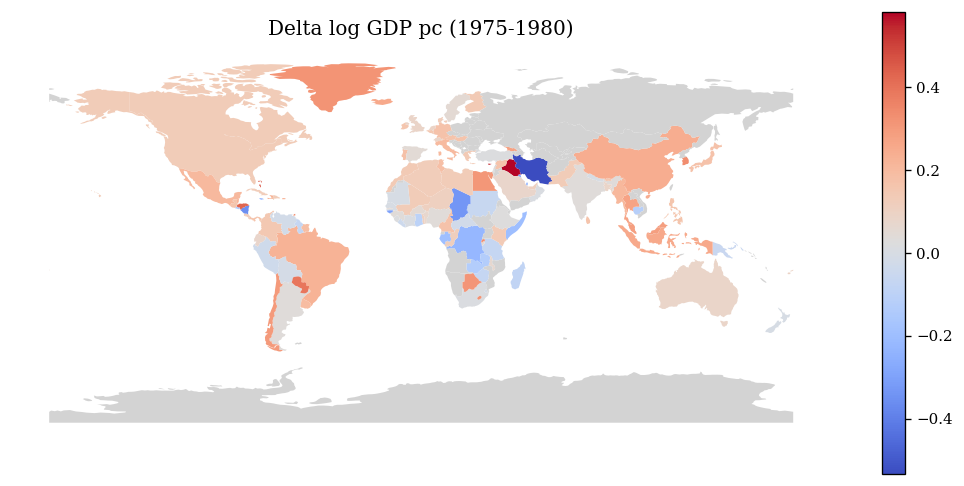

,iso3c,country_name,d_efw
125,KWT,Kuwait,1.650000
178,OMN,Oman,1.460000
163,MUS,Mauritius,1.460000
240,TUR,Turkiye,1.100000
228,TGO,Togo,1.030000
81,GBR,United Kingdom,0.980000
105,IDN,Indonesia,0.910000
181,PAN,Panama,0.830000
199,RWA,Rwanda,0.790000
80,GAB,Gabon,0.770000


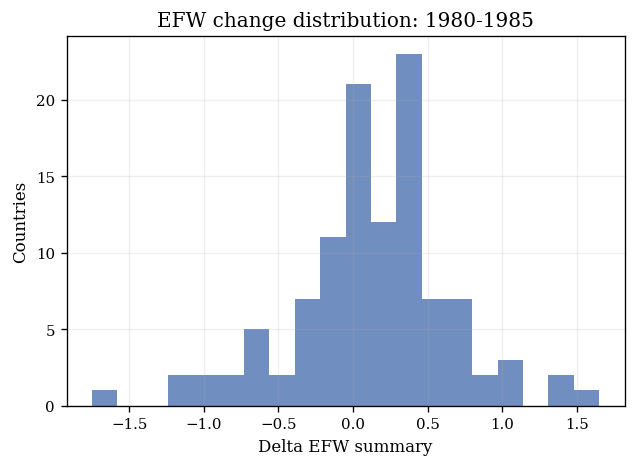

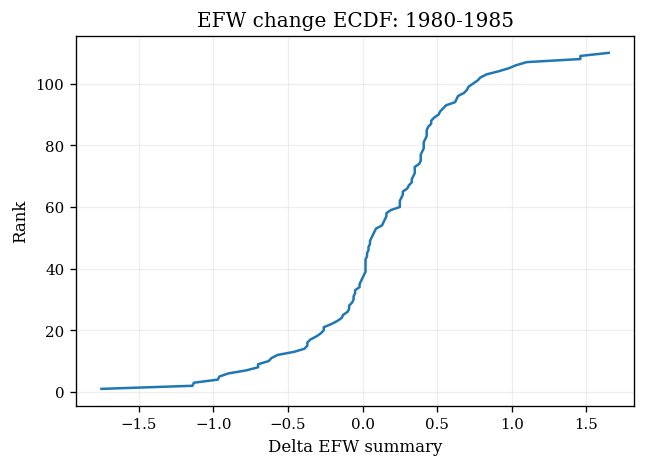

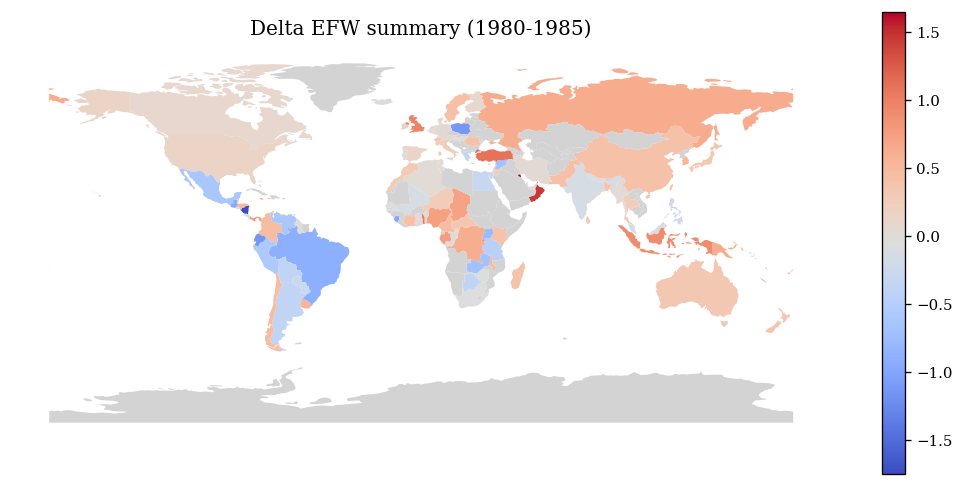

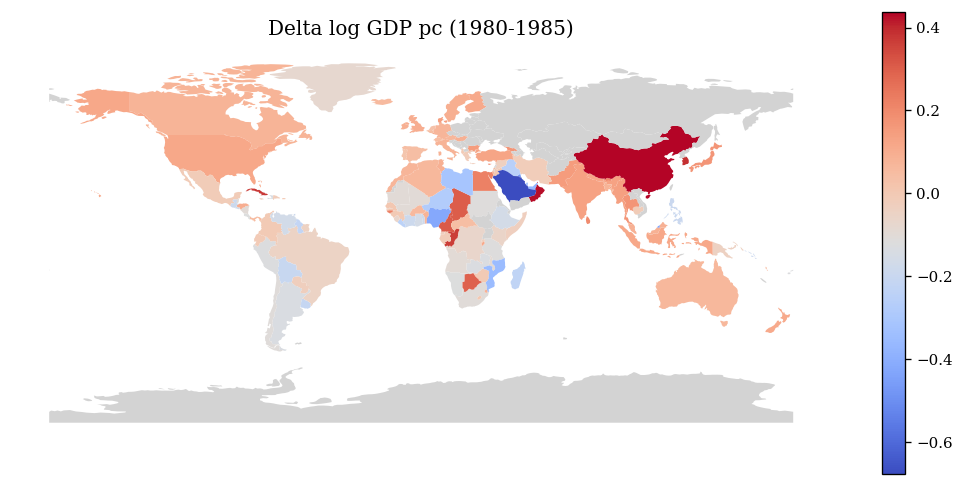

,iso3c,country_name,d_efw
171,NIC,Nicaragua,3.710000
9,ARG,Argentina,3.010000
182,PER,Peru,2.930000
244,UGA,Uganda,2.720000
207,SLV,El Salvador,2.680000
28,BOL,Bolivia,2.490000
183,PHL,Philippines,2.330000
83,GHA,Ghana,2.150000
92,GTM,Guatemala,2.060000
39,CHL,Chile,2.020000


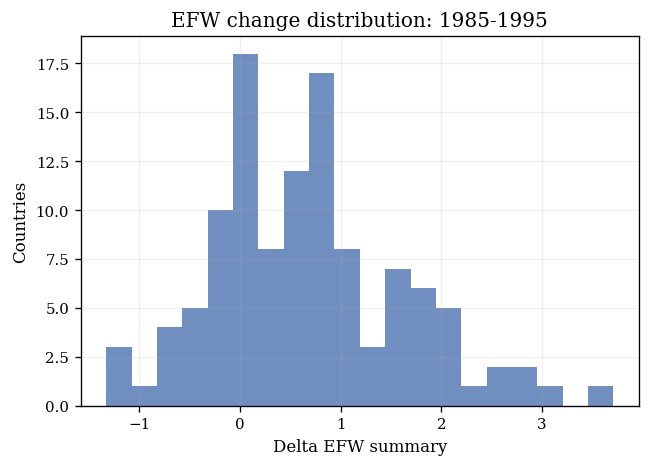

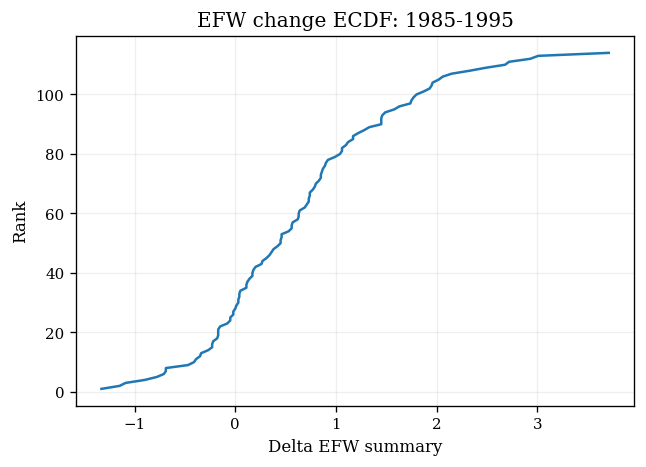

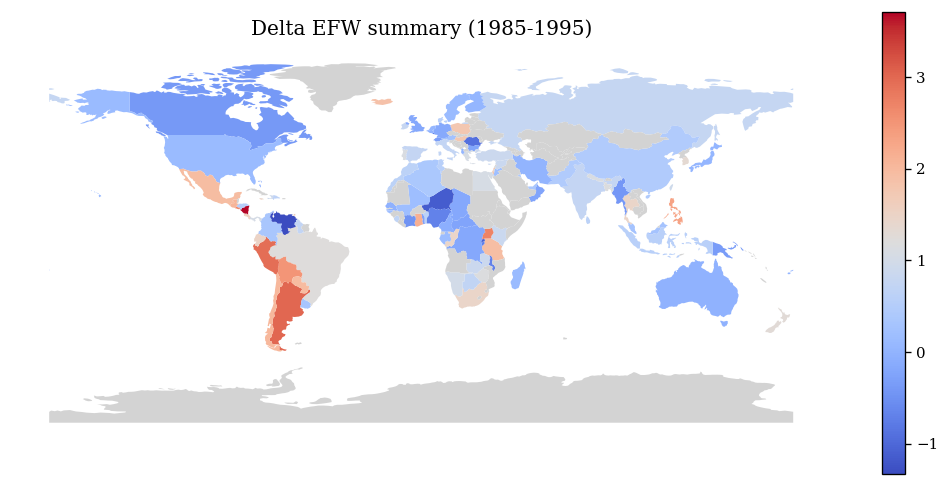

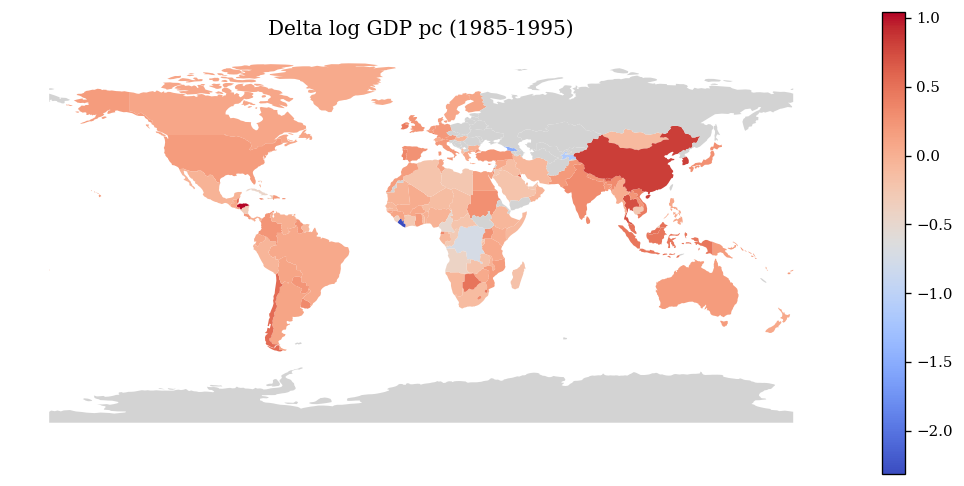

,iso3c,country_name,d_efw
71,EST,Estonia,1.680000
199,RWA,Rwanda,1.300000
182,PER,Peru,1.300000
98,HRV,Croatia,1.300000
29,BRA,Brazil,1.290000
141,LVA,Latvia,1.160000
244,UGA,Uganda,1.140000
170,NGA,Nigeria,1.130000
139,LTU,Lithuania,1.130000
147,MDG,Madagascar,1.080000


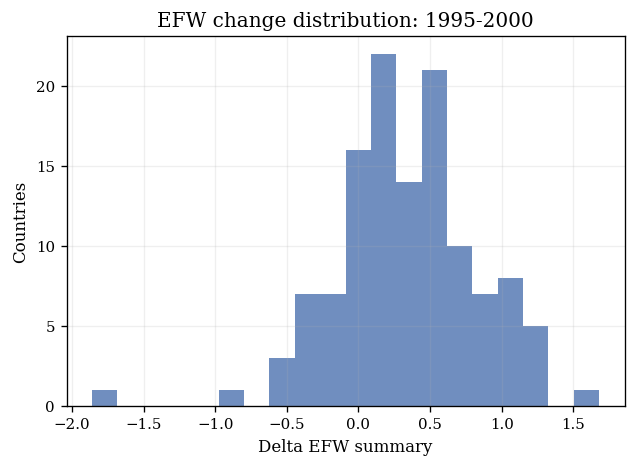

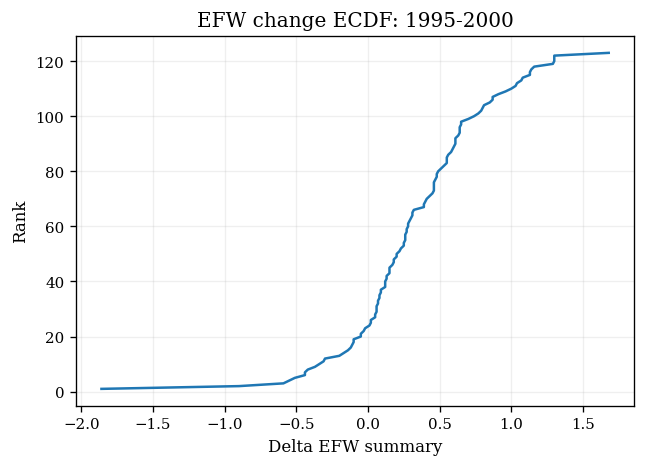

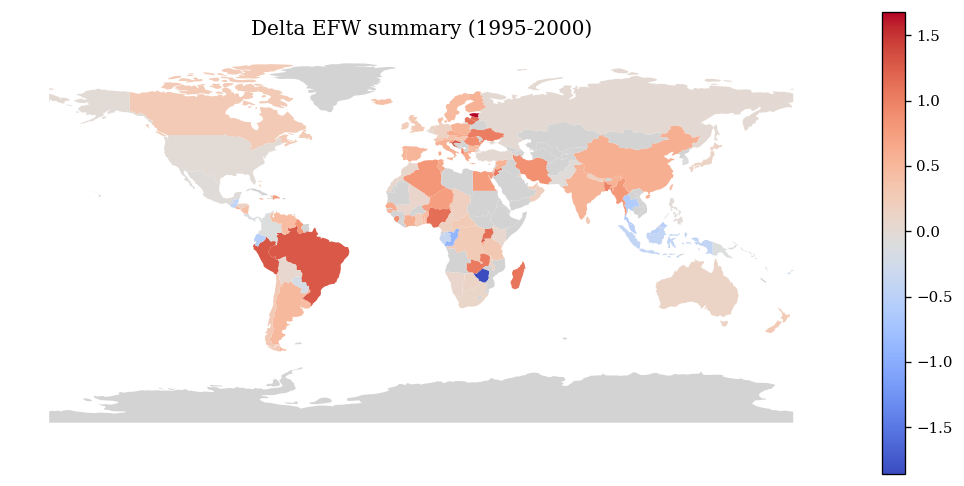

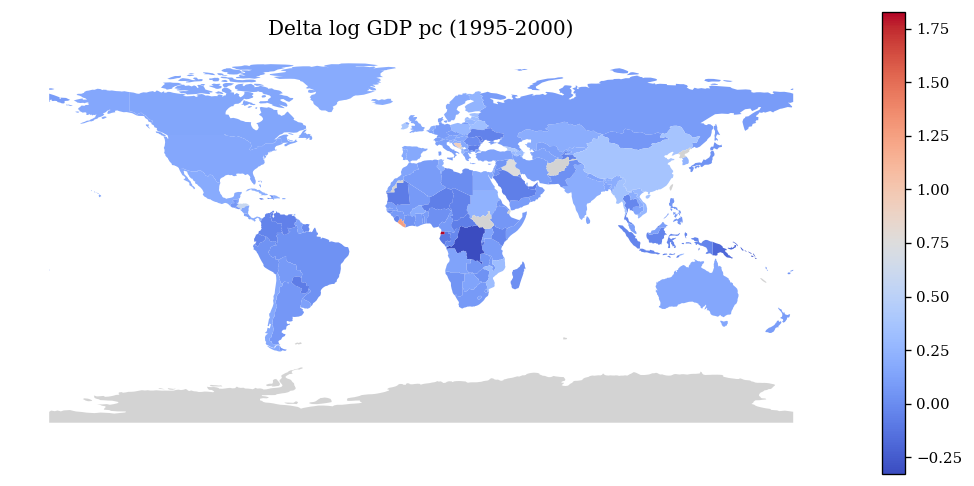

,iso3c,country_name,d_efw
196,QAT,Qatar,1.960000
258,YEM,"Yemen, Rep.",1.750000
230,TJK,Tajikistan,1.480000
86,GMB,"Gambia, The",1.420000
128,LBN,Lebanon,1.320000
111,IRQ,Iraq,1.320000
261,ZWE,Zimbabwe,1.210000
201,SAU,Saudi Arabia,1.210000
4,AGO,Angola,1.040000
25,BLR,Belarus,0.990000


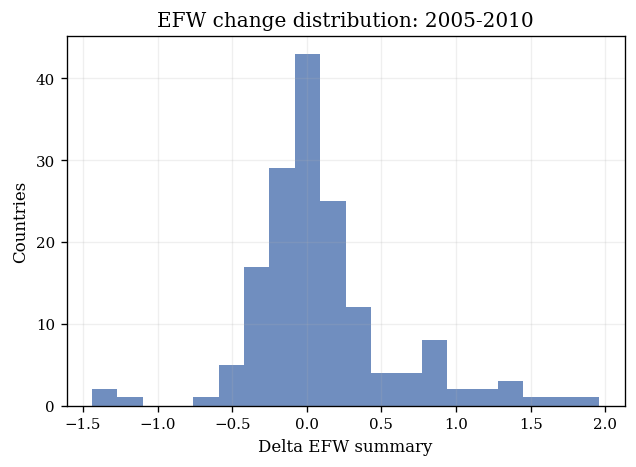

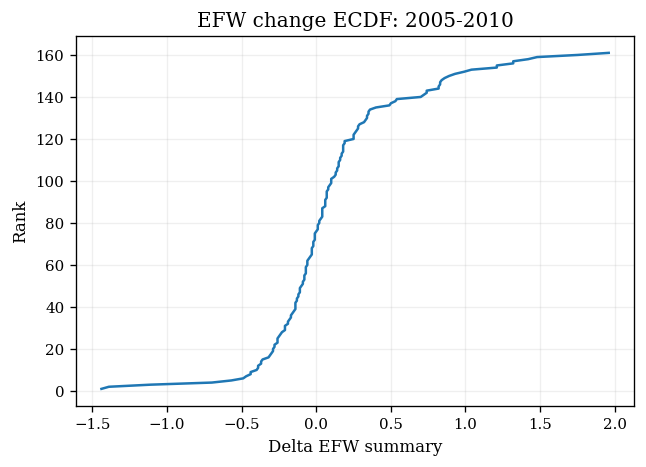

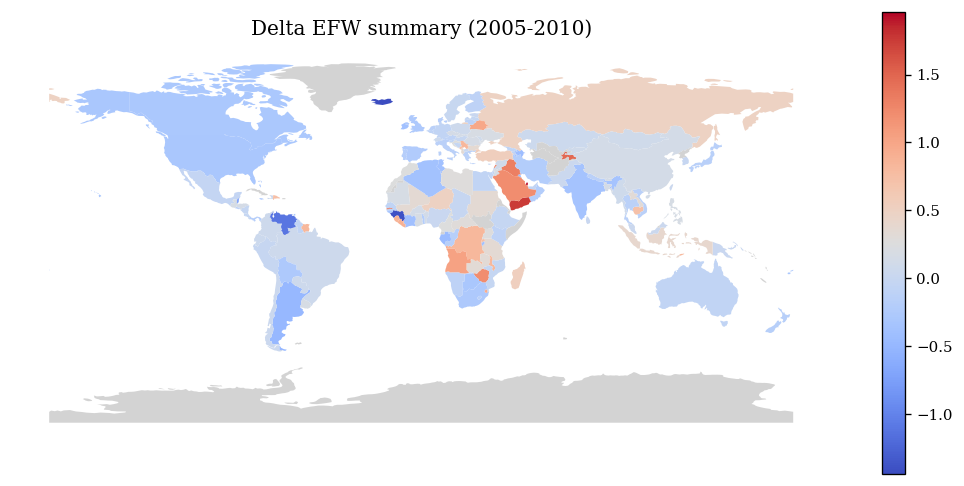

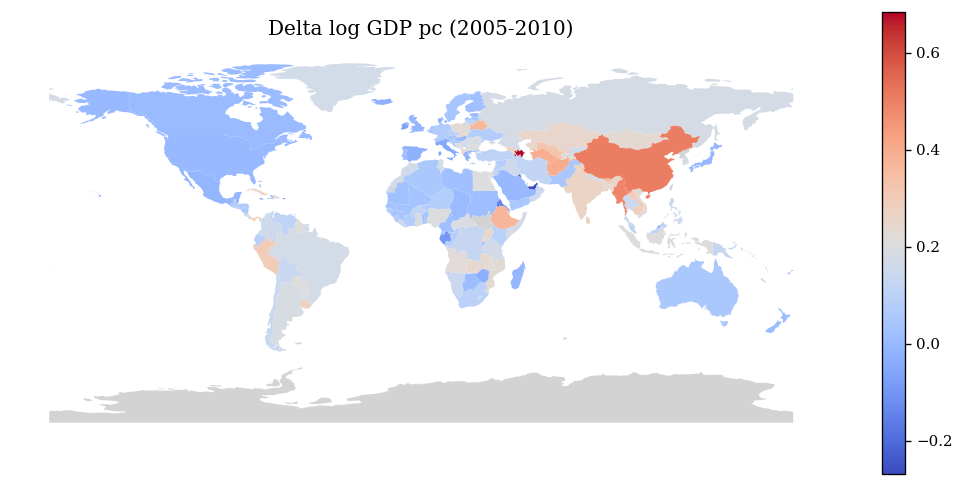

,iso3c,country_name,d_efw
156,MMR,Myanmar,1.340000
85,GIN,Guinea,1.020000
261,ZWE,Zimbabwe,1.000000
222,SYC,Seychelles,0.940000
233,TLS,Timor-Leste,0.930000
130,LBY,Libya,0.810000
165,MYS,Malaysia,0.810000
82,GEO,Georgia,0.700000
112,ISL,Iceland,0.690000
16,BDI,Burundi,0.670000


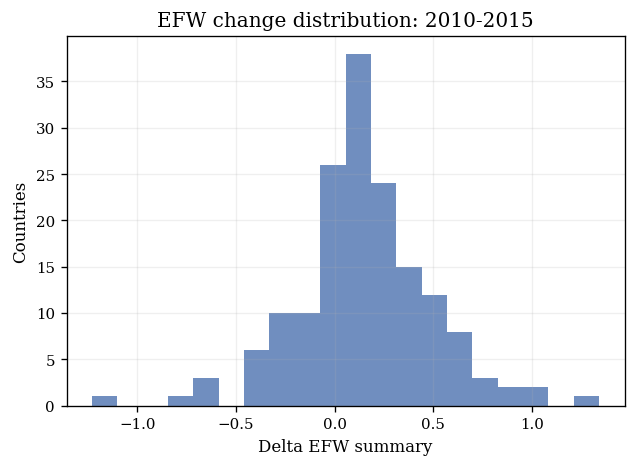

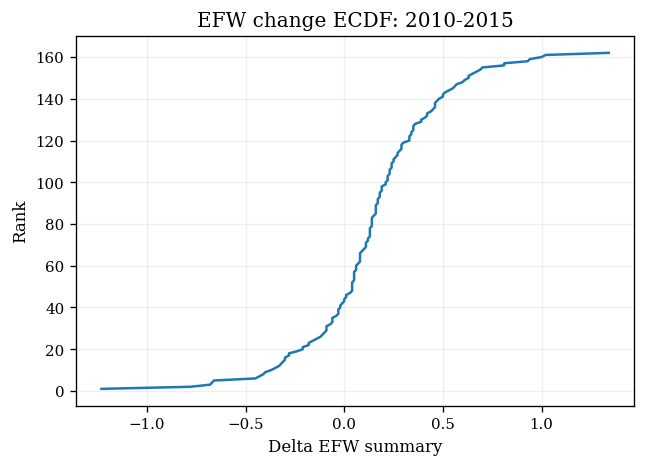

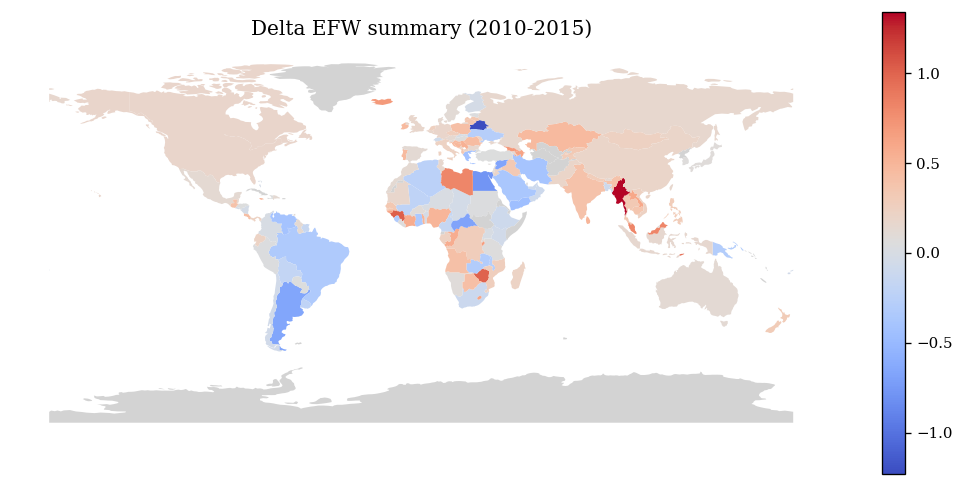

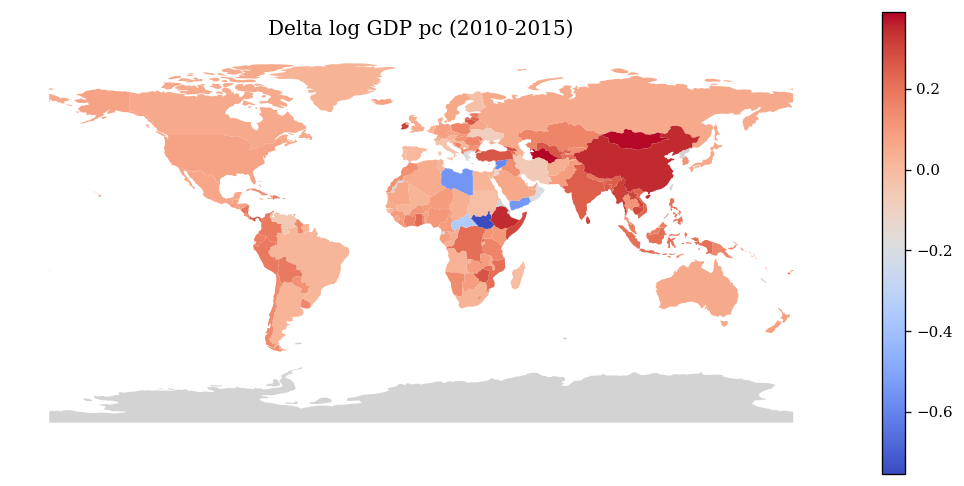

,iso3c,country_name,d_efw
25,BLR,Belarus,1.880000
111,IRQ,Iraq,1.320000
85,GIN,Guinea,1.000000
245,UKR,Ukraine,0.970000
201,SAU,Saudi Arabia,0.770000
34,CAF,Central African Republic,0.580000
156,MMR,Myanmar,0.440000
253,VNM,Viet Nam,0.390000
112,ISL,Iceland,0.380000
18,BEN,Benin,0.370000


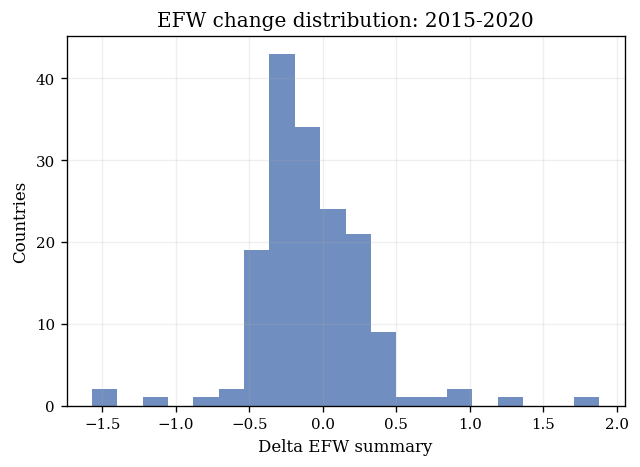

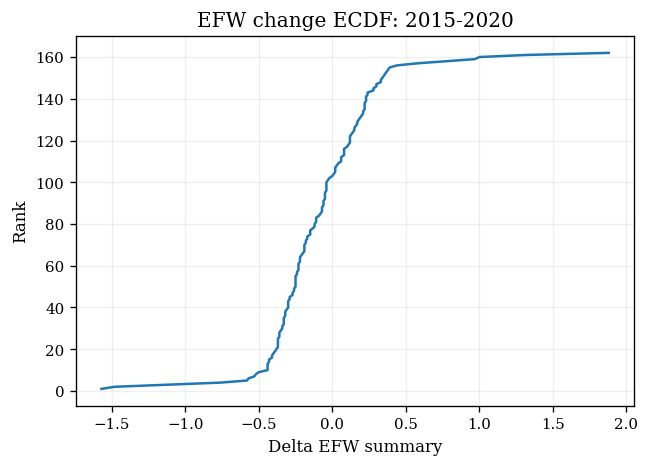

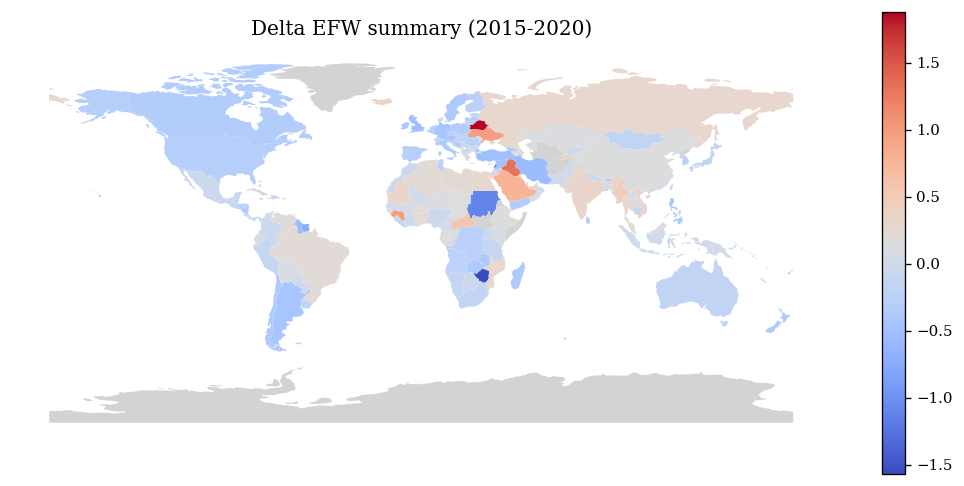

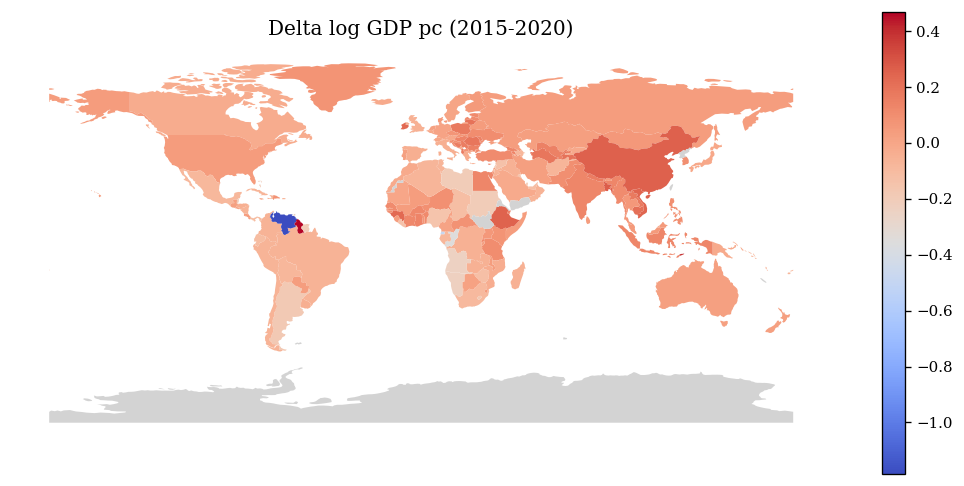

,episode,start,end,mean_change,median_change,share_positive,n
0,oil_shocks_1970_1975,1970,1975,-0.489,-0.365,0.204,98
1,volcker_debt_1975_1985,1975,1985,0.148,0.230,0.654,107
2,volcker_1975_1980,1975,1980,0.015,0.060,0.523,107
3,volcker_1980_1985,1980,1985,0.138,0.145,0.664,110
4,post_communist_1985_1995,1985,1995,0.672,0.595,0.754,114
5,asian_russian_1995_2000,1995,2000,0.339,0.290,0.813,123
6,gfc_2005_2010,2005,2010,0.107,0.020,0.528,161
7,post_gfc_2010_2015,2010,2015,0.150,0.140,0.728,162
8,covid_2015_2020,2015,2020,-0.079,-0.110,0.364,162


In [3]:
fig_dir = OUTPUT_DIR / "figures" / "episodes"
fig_dir.mkdir(parents=True, exist_ok=True)
episode_stats = []

for name, window in episodes.items():
    start = window["start"]
    end = window["end"]
    start_df = panel[panel["year"] == start]
    end_df = panel[panel["year"] == end]
    merged = start_df.merge(end_df, on="iso3c", suffixes=("_start", "_end"))
    if merged.empty:
        continue

    merged["d_efw"] = merged["efw_summary_end"] - merged["efw_summary_start"]
    if "log_gdp_pc_const_end" in merged.columns:
        merged["d_log_gdp_pc_const"] = (
            merged["log_gdp_pc_const_end"] - merged["log_gdp_pc_const_start"]
        )

    leaderboard = merged[["iso3c", "country_name_end", "d_efw"]].dropna()
    leaderboard = leaderboard.rename(columns={"country_name_end": "country_name"})
    leaderboard = leaderboard.sort_values("d_efw", ascending=False)
    leaderboard_path = OUTPUT_DIR / "tables" / f"episode_leaderboards_{name}.csv"
    leaderboard_path.parent.mkdir(parents=True, exist_ok=True)
    leaderboard_table = pd.concat([leaderboard.head(10), leaderboard.tail(10)])
    leaderboard_table.to_csv(leaderboard_path, index=False)
    display(leaderboard_table.style.set_caption(f"Top/bottom changes in {name}"))

    d_efw = merged["d_efw"].dropna()
    if not d_efw.empty:
        episode_stats.append(
            {
                "episode": name,
                "start": start,
                "end": end,
                "mean_change": float(d_efw.mean()),
                "median_change": float(d_efw.median()),
                "share_positive": float((d_efw > 0).mean()),
                "n": int(d_efw.shape[0]),
            }
        )

    fig, ax = plt.subplots(figsize=(6, 4))
    ax.hist(merged["d_efw"].dropna(), bins=20, color="#4C72B0", alpha=0.8)
    ax.set_title(f"EFW change distribution: {start}-{end}")
    ax.set_xlabel("Delta EFW summary")
    ax.set_ylabel("Countries")
    display(fig)
    savefig(fig, fig_dir / f"{name}_dist_efw")
    plt.close(fig)

    fig, ax = plt.subplots(figsize=(6, 4))
    sorted_vals = merged["d_efw"].dropna().sort_values()
    ax.plot(sorted_vals, range(1, len(sorted_vals) + 1))
    ax.set_title(f"EFW change ECDF: {start}-{end}")
    ax.set_xlabel("Delta EFW summary")
    ax.set_ylabel("Rank")
    display(fig)
    savefig(fig, fig_dir / f"{name}_ecdf_efw")
    plt.close(fig)

    map_df = merged[["iso3c", "d_efw"]]
    merged_map = merge_world_data(world, map_df, "iso3c", "d_efw")
    fig, _ = plot_choropleth(
        merged_map,
        "d_efw",
        title=f"Delta EFW summary ({start}-{end})",
        cmap="coolwarm",
        missing_color="lightgrey",
    )
    display(fig)
    savefig(fig, fig_dir / f"{name}_map_efw")
    plt.close(fig)

    if "d_log_gdp_pc_const" in merged.columns:
        map_df = merged[["iso3c", "d_log_gdp_pc_const"]]
        merged_map = merge_world_data(world, map_df, "iso3c", "d_log_gdp_pc_const")
        fig, _ = plot_choropleth(
            merged_map,
            "d_log_gdp_pc_const",
            title=f"Delta log GDP pc ({start}-{end})",
            cmap="coolwarm",
            missing_color="lightgrey",
        )
        display(fig)
        savefig(fig, fig_dir / f"{name}_map_gdp")
        plt.close(fig)

if episode_stats:
    episode_df = pd.DataFrame(episode_stats)
    display(episode_df.style.format(precision=3).set_caption("Episode summary statistics"))

## Interpretation
Episode-level summaries reveal heterogeneous responses to global shocks.
During the 1970-1975 oil shocks, average EFW change is -0.49 with only ~20%
of countries improving, while the 1985-1995 post-communist period shows a
strong average gain of +0.67 with ~75% positive changes. The 2015-2020
COVID window turns negative again (mean -0.08; ~36% positive), illustrating
how global shocks can reverse progress. The distributions and maps highlight
which countries experienced the largest improvements or declines.